# Graph-Based Ni Powder Clustering

Analysis of TDCSophiread graph clustering functionality using the Ni powder dataset.

**Goals:**
1. Process Ni powder TPX3 file to hits
2. Apply graph-based clustering to extract neutron events
3. Analyze graph clustering results and performance
4. Visualize spatial and temporal distributions

**Data:** Ni powder sample - `Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3`

**Algorithm:** Graph-based clustering using connected components with Union-Find

## 1. Setup and Import

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import tdcsophiread as tdc

print(f"TDCSophiread version: {tdc.__version__}")
print(f"Numpy version: {np.__version__}")

# Setup plotting
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

TDCSophiread version: 2.0.0
Numpy version: 2.3.1


## 2. Data File Setup

In [2]:
# Ni powder file path
data_path = "data/"
ni_file = "Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3"
ni_full_path = os.path.join(data_path, ni_file)

# Verify file exists
if os.path.exists(ni_full_path):
    size_mb = os.path.getsize(ni_full_path) / (1024 * 1024)
    print(f"✅ Ni powder file found: {ni_file}")
    print(f"   Size: {size_mb:.1f} MB")
else:
    print(f"❌ File not found: {ni_full_path}")
    print("Please ensure the data file is in the correct location")

✅ Ni powder file found: Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3
   Size: 5652.0 MB


## 3. Raw Data → Hits Processing

In [3]:
print("=== Processing TPX3 file to hits ===")

start_time = time.time()

# Process the file using TDCSophiread (high-level convenience function)
# Returns TDCHitView for zero-copy numpy access
hit_view = tdc.process_tpx3(ni_full_path, parallel=True)

# Convert to numpy array (zero-copy)
hits = np.array(hit_view, copy=False)

processing_time = time.time() - start_time

print(f"✅ Processing completed in {processing_time:.2f} seconds")
print(f"✅ Total hits extracted: {len(hits):,}")
print(f"✅ Processing rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")

# Display hit data structure
print("\nHit data structure:")
for field in hits.dtype.names:
    array = hits[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    print(f"    range: {array.min()} - {array.max()}")

=== Processing TPX3 file to hits ===
✅ Processing completed in 27.22 seconds
✅ Total hits extracted: 736,028,562
✅ Processing rate: 27.0 M hits/second

Hit data structure:
  tof: uint32, shape (736028562,)
    range: 0 - 666656
  x: uint16, shape (736028562,)
    range: 0 - 513
  y: uint16, shape (736028562,)
    range: 0 - 513
  timestamp: uint32, shape (736028562,)
    range: 30348 - 1074755785
  tot: uint16, shape (736028562,)
    range: 1 - 807
  chip_id: uint8, shape (736028562,)
    range: 0 - 3
  cluster_id: int32, shape (736028562,)
    range: -1 - -1


## 4. Graph Clustering Configuration

In [4]:
print("=== Setting up graph clustering configuration ===")

# Create neutron processing configuration
config = tdc.NeutronProcessingConfig()

# Configure for graph clustering
config.clustering.algorithm = "graph"

# Graph clustering parameters
config.clustering.graph.radius = 5.0  # Same as ABS default
config.clustering.graph.min_cluster_size = 1
config.clustering.graph.grid_size = 5.0
config.clustering.graph.enable_spatial_hash = True

# Use temporal window from ABS config for fair comparison
config.clustering.abs.neutron_correlation_window = 75.0  # ns

# Extraction configuration (same as ABS notebook)
config.extraction.algorithm = "simple_centroid"
config.extraction.super_resolution_factor = 8.0
config.extraction.weighted_by_tot = True
config.extraction.min_tot_threshold = 0

# Temporal processing configuration
config.temporal.num_workers = 0  # Auto-detect
config.temporal.min_batch_size = 1000
config.temporal.max_batch_size = 100000
config.temporal.enable_deduplication = False

print("Neutron processing configuration:")
print(f"  Clustering algorithm: {config.clustering.algorithm}")
print(f"  Extraction algorithm: {config.extraction.algorithm}")

print("\nGraph clustering parameters:")
print(f"  Spatial radius: {config.clustering.graph.radius} pixels")
print(f"  Min cluster size: {config.clustering.graph.min_cluster_size} hits")
print(f"  Grid size: {config.clustering.graph.grid_size}")
print(f"  Spatial hash enabled: {config.clustering.graph.enable_spatial_hash}")
print(f"  Temporal window: {config.clustering.abs.neutron_correlation_window} ns")

print("\nCentroid extraction parameters:")
print(f"  Super resolution: {config.extraction.super_resolution_factor}x")
print(f"  TOT weighted: {config.extraction.weighted_by_tot}")
print(f"  Min TOT threshold: {config.extraction.min_tot_threshold}")

print("\nTemporal processing parameters:")
print(f"  Number of workers: {config.temporal.num_workers}")
print(f"  Min batch size: {config.temporal.min_batch_size}")
print(f"  Max batch size: {config.temporal.max_batch_size}")

=== Setting up graph clustering configuration ===
Neutron processing configuration:
  Clustering algorithm: graph
  Extraction algorithm: simple_centroid

Graph clustering parameters:
  Spatial radius: 5.0 pixels
  Min cluster size: 1 hits
  Grid size: 5.0
  Spatial hash enabled: True
  Temporal window: 75.0 ns

Centroid extraction parameters:
  Super resolution: 8.0x
  TOT weighted: True
  Min TOT threshold: 0

Temporal processing parameters:
  Number of workers: 0
  Min batch size: 1000
  Max batch size: 100000


## 5. Hits → Neutrons Graph Clustering

In [5]:
print("=== Graph clustering hits to neutrons ===")
print(f"Input: {len(hits):,} hits")
print("\nNote: Graph clustering is computationally more intensive than ABS.")
print("This may take several minutes for large datasets...\n")

start_time = time.time()

# Process hits to neutrons using graph clustering
neutron_view = tdc.process_hits_to_neutrons(hits, config)

clustering_time = time.time() - start_time

print(f"✅ Graph clustering completed in {clustering_time:.2f} seconds")

=== Graph clustering hits to neutrons ===
Input: 736,028,562 hits

Note: Graph clustering is computationally more intensive than ABS.
This may take several minutes for large datasets...

✅ Graph clustering completed in 102.40 seconds


In [6]:
print("Exposing neutron data as numpy array for zero-copy access")
start_time = time.time()
# Convert to numpy array (zero-copy)
neutrons = np.array(neutron_view, copy=False)
processing_time = time.time() - start_time
print(f"✅ Neutron data exposed in {processing_time:.2f} seconds")
print(f"✅ Output neutrons: {len(neutrons):,}")
print(f"✅ Clustering rate: {len(hits) / clustering_time:.0f} hits/second")

Exposing neutron data as numpy array for zero-copy access
✅ Neutron data exposed in 0.00 seconds
✅ Output neutrons: 290,318,503
✅ Clustering rate: 7187562 hits/second


In [7]:
# Calculate clustering efficiency
efficiency = len(neutrons) / len(hits)
print(f"✅ Neutron extraction efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")

# Display neutron data structure
print("\nNeutron data structure:")
for field in neutrons.dtype.names:
    array = neutrons[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    if field in ["x", "y"]:
        print(f"    range: {array.min():.2f} - {array.max():.2f} (sub-pixel)")
    else:
        print(f"    range: {array.min()} - {array.max()}")

✅ Neutron extraction efficiency: 0.394439 (39.4439%)

Neutron data structure:
  x: float64, shape (290318503,)
    range: 0.00 - 4104.00 (sub-pixel)
  y: float64, shape (290318503,)
    range: 0.00 - 4104.00 (sub-pixel)
  tof: uint32, shape (290318503,)
    range: 0 - 666656
  tot: uint16, shape (290318503,)
    range: 1 - 2296
  n_hits: uint16, shape (290318503,)
    range: 1 - 87
  chip_id: uint8, shape (290318503,)
    range: 0 - 3
  reserved: uint8, shape (290318503,)
    range: 0 - 0


## 6. Graph Clustering Results Analysis

In [8]:
print("=== Graph Clustering Results Analysis ===")

# Get neutron fields directly
n_hits_field = neutrons["n_hits"]
x_field = neutrons["x"]
y_field = neutrons["y"]

# Cluster size distribution
cluster_sizes, counts = np.unique(n_hits_field, return_counts=True)
print(f"\nCluster size distribution (showing first 10):")
for size, count in zip(cluster_sizes[:10], counts[:10]):
    percentage = 100 * count / len(neutrons)
    print(f"  {size} hits: {count:,} neutrons ({percentage:.2f}%)")

if len(cluster_sizes) > 10:
    print(f"  ... (total {len(cluster_sizes)} different cluster sizes)")

# Single vs multi-hit clusters
single_hit = counts[cluster_sizes == 1][0] if 1 in cluster_sizes else 0
multi_hit = len(neutrons) - single_hit
print(f"\nCluster composition:")
print(
    f"  Single-hit neutrons: {single_hit:,} ({100 * single_hit / len(neutrons):.1f}%)"
)
print(f"  Multi-hit neutrons: {multi_hit:,} ({100 * multi_hit / len(neutrons):.1f}%)")
print(f"  Mean cluster size: {n_hits_field.mean():.1f} hits")
print(f"  Max cluster size: {n_hits_field.max()} hits")

# Sub-pixel precision check
x_fractional = x_field - np.floor(x_field)
y_fractional = y_field - np.floor(y_field)
non_integer_x = np.sum(x_fractional > 0.001)
non_integer_y = np.sum(y_fractional > 0.001)

print(f"\nSub-pixel precision:")
print(
    f"  Non-integer X coordinates: {non_integer_x:,} ({100 * non_integer_x / len(neutrons):.1f}%)"
)
print(
    f"  Non-integer Y coordinates: {non_integer_y:,} ({100 * non_integer_y / len(neutrons):.1f}%)"
)
print(f"  X fractional range: {x_fractional.min():.3f} - {x_fractional.max():.3f}")
print(f"  Y fractional range: {y_fractional.min():.3f} - {y_fractional.max():.3f}")

# Graph clustering specific analysis
print(f"\nGraph clustering characteristics:")
print(f"  Algorithm: Connected components with Union-Find")
print(f"  Spatial constraint: {config.clustering.graph.radius} pixel radius")
print(
    f"  Temporal constraint: {config.clustering.abs.neutron_correlation_window} ns window"
)
print(
    f"  Grid optimization: {config.clustering.graph.grid_size}x{config.clustering.graph.grid_size} spatial hash"
)

=== Graph Clustering Results Analysis ===

Cluster size distribution (showing first 10):
  1 hits: 102,247,431 neutrons (35.22%)
  2 hits: 75,319,550 neutrons (25.94%)
  3 hits: 38,392,794 neutrons (13.22%)
  4 hits: 42,524,996 neutrons (14.65%)
  5 hits: 13,815,921 neutrons (4.76%)
  6 hits: 9,218,116 neutrons (3.18%)
  7 hits: 4,285,618 neutrons (1.48%)
  8 hits: 1,952,614 neutrons (0.67%)
  9 hits: 1,042,102 neutrons (0.36%)
  10 hits: 528,621 neutrons (0.18%)
  ... (total 70 different cluster sizes)

Cluster composition:
  Single-hit neutrons: 102,247,431 (35.2%)
  Multi-hit neutrons: 188,071,072 (64.8%)
  Mean cluster size: 2.5 hits
  Max cluster size: 87 hits

Sub-pixel precision:
  Non-integer X coordinates: 143,850,503 (49.5%)
  Non-integer Y coordinates: 123,615,743 (42.6%)
  X fractional range: 0.000 - 0.999
  Y fractional range: 0.000 - 0.999

Graph clustering characteristics:
  Algorithm: Connected components with Union-Find
  Spatial constraint: 5.0 pixel radius
  Temporal

## 7. Spatial Distribution Visualization

In [9]:
det_venus_config = tdc.DetectorConfig.venus_defaults()

det_venus_config.get_chip_size_x(), det_venus_config.get_chip_size_y()

(256, 256)

=== Creating spatial distribution visualizations ===

Creating hits 2D histogram...
Creating neutrons 2D histogram...


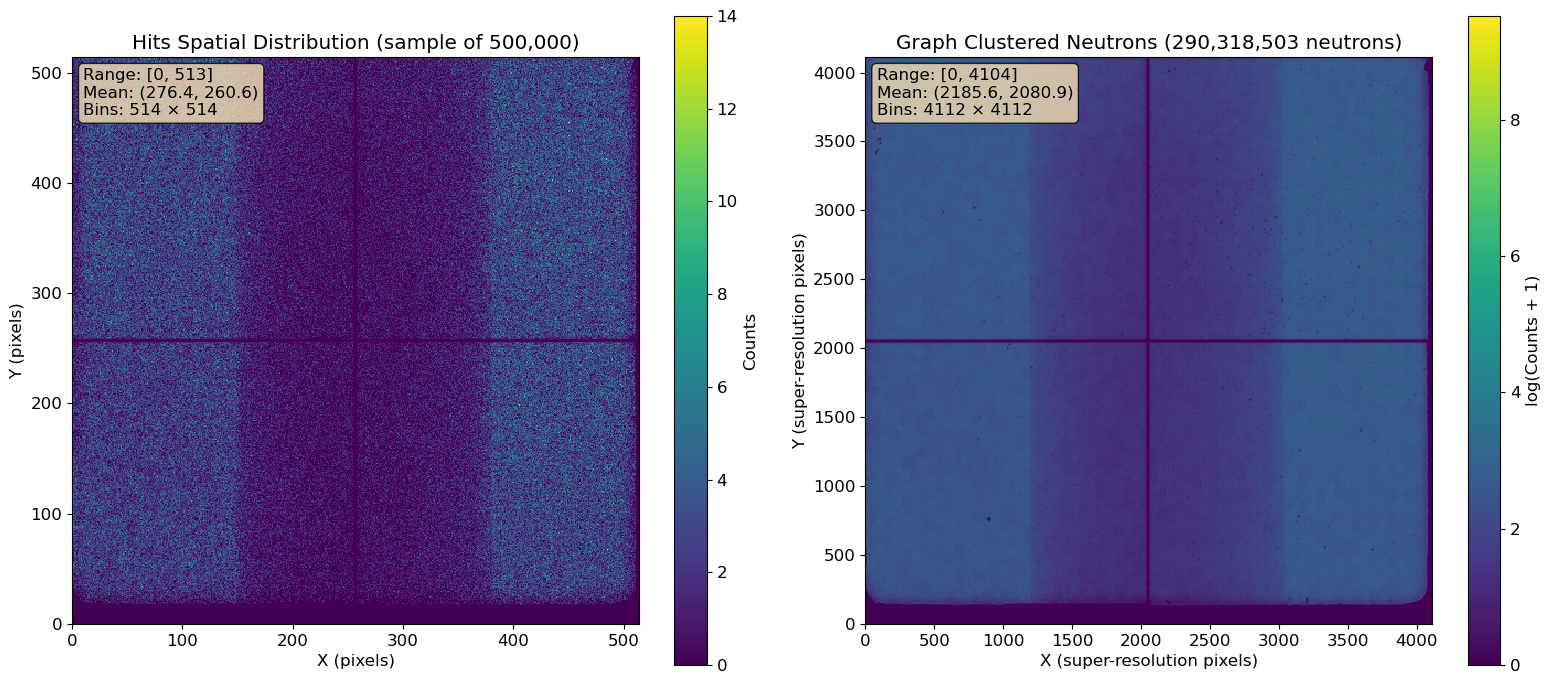


=== Spatial Distribution Analysis ===
Detector configuration: 514×514 pixels
Super-resolution factor: 8.0x

Hits (native pixels):
  X range: 0 - 513
  Y range: 0 - 513
  Total hits: 736,028,562

Neutrons (super-resolution pixels):
  X range: 0.0 - 4104.0
  Y range: 0.0 - 4104.0
  Total neutrons: 290,318,503
  Data reduction: 2.5:1


In [10]:
print("=== Creating spatial distribution visualizations ===")

# VENUS detector has 514x514 pixels (256*2 + 2 pixel gap)
DETECTOR_PIXELS = det_venus_config.get_chip_size_x() * 2 + 2

# use super-resolution factor from config
NEUTRON_SUPER_RES = config.extraction.super_resolution_factor

# Create figure with two subplots for better comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Hits distribution (native pixels)
print("\nCreating hits 2D histogram...")
# Sample hits for performance
sample_size = 500_000
indices = np.random.choice(len(hits), sample_size, replace=False)
hits_x_sample = hits["x"][indices]
hits_y_sample = hits["y"][indices]

# Use 514 bins for native pixel data
hist_hits, x_edges, y_edges = np.histogram2d(
    hits_x_sample,
    hits_y_sample,
    bins=DETECTOR_PIXELS,
    range=[[0, DETECTOR_PIXELS], [0, DETECTOR_PIXELS]],
)

im1 = ax1.imshow(
    hist_hits,
    origin="lower",
    aspect="equal",
    extent=[0, DETECTOR_PIXELS, 0, DETECTOR_PIXELS],
    cmap="viridis",
    interpolation="none",
)
ax1.set_xlabel("X (pixels)")
ax1.set_ylabel("Y (pixels)")
ax1.set_title(f"Hits Spatial Distribution (sample of {sample_size:,})")
plt.colorbar(im1, ax=ax1, label="Counts")

# Add statistics
stats_text = f"Range: [{hits_x_sample.min()}, {hits_x_sample.max()}]\n"
stats_text += f"Mean: ({hits_x_sample.mean():.1f}, {hits_y_sample.mean():.1f})\n"
stats_text += f"Bins: {DETECTOR_PIXELS} × {DETECTOR_PIXELS}"
ax1.text(
    0.02,
    0.98,
    stats_text,
    transform=ax1.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Neutrons distribution (super-resolution pixels)
print("Creating neutrons 2D histogram...")
# Use detector and clustering configuration to determine bins
NEUTRON_BINS = int(DETECTOR_PIXELS * NEUTRON_SUPER_RES)
neutrons_x = neutrons["x"]
neutrons_y = neutrons["y"]
x_min, x_max = neutrons_x.min(), neutrons_x.max()
y_min, y_max = neutrons_y.min(), neutrons_y.max()

hist_neutrons, x_edges_n, y_edges_n = np.histogram2d(
    neutrons_x,
    neutrons_y,
    bins=NEUTRON_BINS,
    range=[[0, NEUTRON_BINS], [0, NEUTRON_BINS]],
)

im2 = ax2.imshow(
    np.log1p(hist_neutrons),
    origin="lower",
    aspect="equal",
    extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
    cmap="viridis",
    interpolation="gaussian",
)
ax2.set_xlabel("X (super-resolution pixels)")
ax2.set_ylabel("Y (super-resolution pixels)")
ax2.set_title(f"Graph Clustered Neutrons ({len(neutrons):,} neutrons)")
plt.colorbar(im2, ax=ax2, label="log(Counts + 1)")

# Add statistics
stats_text = f"Range: [{neutrons_x.min():.0f}, {neutrons_x.max():.0f}]\n"
stats_text += f"Mean: ({neutrons_x.mean():.1f}, {neutrons_y.mean():.1f})\n"
stats_text += f"Bins: {NEUTRON_BINS} × {NEUTRON_BINS}"
ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n=== Spatial Distribution Analysis ===")
print(f"Detector configuration: {DETECTOR_PIXELS}×{DETECTOR_PIXELS} pixels")
print(f"Super-resolution factor: {NEUTRON_SUPER_RES}x")

print("\nHits (native pixels):")
print(f"  X range: {hits['x'].min()} - {hits['x'].max()}")
print(f"  Y range: {hits['y'].min()} - {hits['y'].max()}")
print(f"  Total hits: {len(hits):,}")

print("\nNeutrons (super-resolution pixels):")
print(f"  X range: {neutrons_x.min():.1f} - {neutrons_x.max():.1f}")
print(f"  Y range: {neutrons_y.min():.1f} - {neutrons_y.max():.1f}")
print(f"  Total neutrons: {len(neutrons):,}")
print(f"  Data reduction: {len(hits) / len(neutrons):.1f}:1")

## 8. TOF Analysis

=== TOF Analysis ===
TOF ranges:
  Hits: 0.000 - 16.666 ms
  Neutrons: 0.000 - 16.666 ms


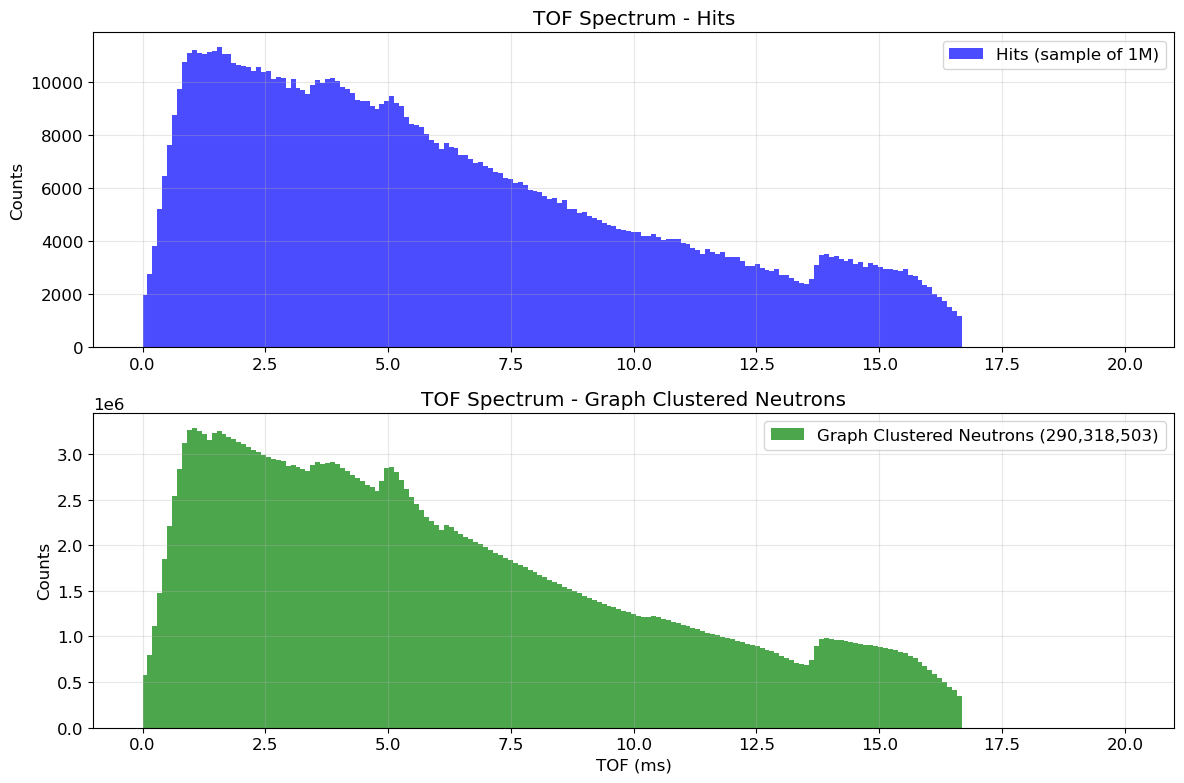

In [11]:
print("=== TOF Analysis ===")

# Convert TOF to milliseconds
hits_tof_ms = hits["tof"] * 25 / 1e6  # 25ns units to ms
neutrons_tof = neutrons["tof"]
neutrons_tof_ms = neutrons_tof * 25 / 1e6

print(f"TOF ranges:")
print(f"  Hits: {hits_tof_ms.min():.3f} - {hits_tof_ms.max():.3f} ms")
print(f"  Neutrons: {neutrons_tof_ms.min():.3f} - {neutrons_tof_ms.max():.3f} ms")

# Create TOF spectra
tof_bins = np.linspace(0, 20, 200)  # 0-20 ms in 200 bins

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Hits TOF spectrum (sample for performance)
sample_indices = np.random.choice(len(hits_tof_ms), 1000000, replace=False)
ax1.hist(
    hits_tof_ms[sample_indices],
    bins=tof_bins,
    alpha=0.7,
    label=f"Hits (sample of 1M)",
    color="blue",
)
ax1.set_ylabel("Counts")
ax1.set_title("TOF Spectrum - Hits")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Neutrons TOF spectrum
ax2.hist(
    neutrons_tof_ms,
    bins=tof_bins,
    alpha=0.7,
    label=f"Graph Clustered Neutrons ({len(neutrons_tof_ms):,})",
    color="green",
)
ax2.set_xlabel("TOF (ms)")
ax2.set_ylabel("Counts")
ax2.set_title("TOF Spectrum - Graph Clustered Neutrons")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Summary and Performance Analysis

In [12]:
print("=== Graph Clustering Summary ===")
print()
print("✅ TPX3 file processing: SUCCESS")
print(f"   - Processed {len(hits):,} hits")
print(f"   - Rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")
print()
print("✅ Graph clustering pipeline: SUCCESS")
print("   - Algorithm: Graph-based connected components")
print(f"   - Input: {len(hits):,} hits")
print(f"   - Output: {len(neutrons):,} neutrons")
print(f"   - Efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")
print(f"   - Processing time: {clustering_time:.2f} seconds")
print(f"   - Rate: {len(hits) / clustering_time / 1e6:.3f} M hits/second")
print()
print("✅ Sub-pixel precision: CONFIRMED")
print(f"   - {non_integer_x:,} neutrons have non-integer X coordinates")
print(f"   - {non_integer_y:,} neutrons have non-integer Y coordinates")
print()
print("✅ Cluster analysis: COMPLETE")
print(f"   - Mean cluster size: {n_hits_field.mean():.1f} hits")
print(f"   - Cluster size range: {n_hits_field.min()} - {n_hits_field.max()} hits")
print(
    f"   - Multi-hit clusters: {multi_hit:,} ({100 * multi_hit / len(neutrons):.1f}%)"
)
print()
print("📊 Graph Clustering Characteristics:")
print(f"   - Connects hits within {config.clustering.graph.radius} pixel radius")
print(
    f"   - Uses {config.clustering.graph.grid_size}x{config.clustering.graph.grid_size} spatial grid for efficiency"
)
print(
    f"   - Enforces {config.clustering.abs.neutron_correlation_window} ns temporal window"
)
print("   - Union-Find algorithm for connected components")

# Performance comparison note
print("\n📈 Performance Note:")
print("   Graph clustering is computationally more intensive than ABS clustering.")
print("   It provides different clustering behavior that may be more suitable")
print("   for certain physics scenarios where spatial connectivity is important.")

=== Graph Clustering Summary ===

✅ TPX3 file processing: SUCCESS
   - Processed 736,028,562 hits
   - Rate: 875036.2 M hits/second

✅ Graph clustering pipeline: SUCCESS
   - Algorithm: Graph-based connected components
   - Input: 736,028,562 hits
   - Output: 290,318,503 neutrons
   - Efficiency: 0.394439 (39.4439%)
   - Processing time: 102.40 seconds
   - Rate: 7.188 M hits/second

✅ Sub-pixel precision: CONFIRMED
   - 143,850,503 neutrons have non-integer X coordinates
   - 123,615,743 neutrons have non-integer Y coordinates

✅ Cluster analysis: COMPLETE
   - Mean cluster size: 2.5 hits
   - Cluster size range: 1 - 87 hits
   - Multi-hit clusters: 188,071,072 (64.8%)

📊 Graph Clustering Characteristics:
   - Connects hits within 5.0 pixel radius
   - Uses 5.0x5.0 spatial grid for efficiency
   - Enforces 75.0 ns temporal window
   - Union-Find algorithm for connected components

📈 Performance Note:
   Graph clustering is computationally more intensive than ABS clustering.
   It pro